In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.axisbelow':    True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'legend.frameon':    False,
    'figure.dpi':        150,
})

COLORS = {
    'synthetic': '#2166ac',
    'lightbox':  '#4f0942',
    'sunlamp':   '#d6604d',
}
LABELS = {
    'synthetic': 'Synthetic (validation)',
    'lightbox':  'Lightbox HIL',
    'sunlamp':   'Sunlamp HIL',
}
DOMAINS = ['synthetic', 'lightbox', 'sunlamp']

In [7]:
scores = {}
for domain in DOMAINS:
    scores[domain] = np.load(RESULTS_DIR / f'anomaly_scores_gmm_{domain}.npy')

print(f"{'Domain':<12} {'N':>6} {'Mean':>10} {'Std':>10} {'P25':>10} {'Median':>10} {'P75':>10} {'P95':>10}")
print('-' * 80)
for domain in DOMAINS:
    s = scores[domain]
    print(f"{domain:<12} {len(s):>6} {s.mean():>10.2f} {s.std():>10.2f} "
          f"{np.percentile(s,25):>10.2f} {np.median(s):>10.2f} "
          f"{np.percentile(s,75):>10.2f} {np.percentile(s,95):>10.2f}")

Domain            N       Mean        Std        P25     Median        P75        P95
--------------------------------------------------------------------------------
synthetic      1001     -15.11       8.51     -21.77     -15.49      -8.73      -1.65
lightbox       1001   15692.57   12156.22    6565.77    9205.45   23420.49   38927.15
sunlamp        1001  159881.73   62163.90   99209.61  154417.30  210032.83  267902.50


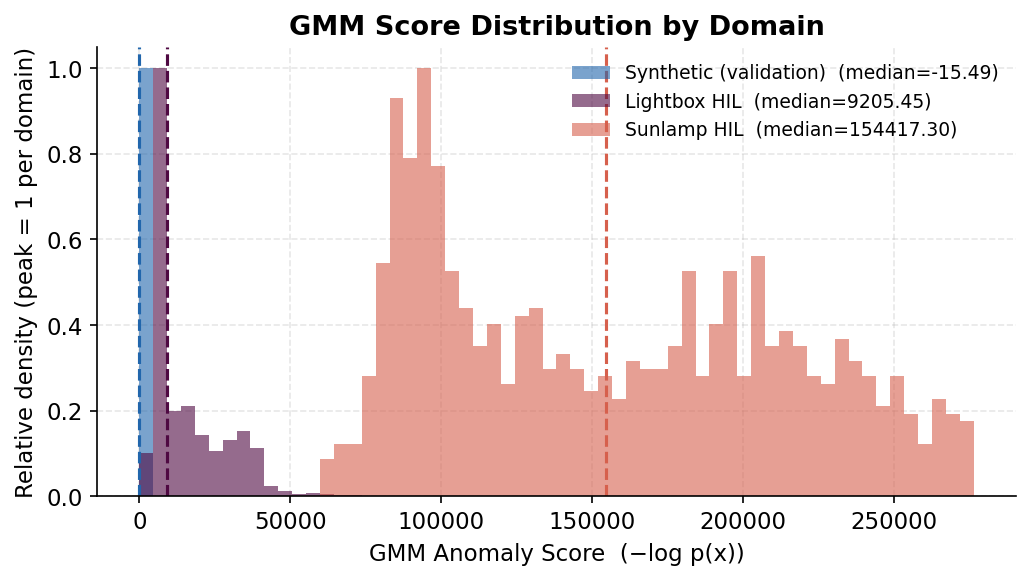

In [8]:
# Overlay histogram — each domain normalized to its own peak so all three are
# visible despite potentially different density scales.
fig, ax = plt.subplots(figsize=(7, 4))

all_scores = np.concatenate([scores[d] for d in DOMAINS])
bins = np.linspace(all_scores.min(), np.percentile(all_scores, 99), 61)

for domain in DOMAINS:
    s = scores[domain]
    counts, edges = np.histogram(s, bins=bins)
    rel = counts / counts.max()
    widths = np.diff(edges)
    ax.bar(
        edges[:-1], rel, width=widths, align='edge',
        color=COLORS[domain], alpha=0.6,
        label=f"{LABELS[domain]}  (median={np.median(s):.2f})",
    )
    ax.axvline(np.median(s), color=COLORS[domain], linestyle='--', linewidth=1.5)

ax.set_xlabel('GMM Anomaly Score  (−log p(x))')
ax.set_ylabel('Relative density (peak = 1 per domain)')
ax.set_title('GMM Score Distribution by Domain', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gmm_scores_overlay.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'gmm_scores_overlay.png', bbox_inches='tight')
plt.show()

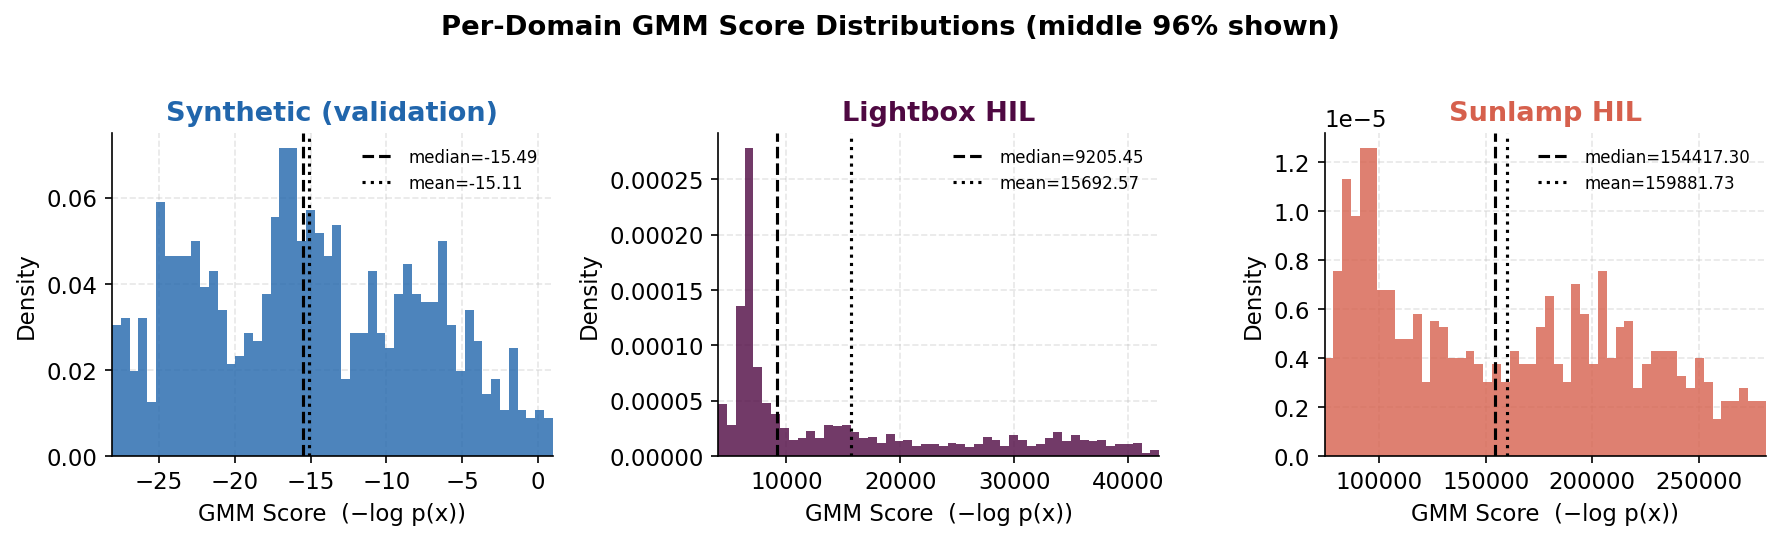

In [10]:
# Per-domain histograms on linear scale — shows within-domain shape
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, domain in zip(axes, DOMAINS):
    s = scores[domain]
    floor = np.percentile(s, 2)
    cap = np.percentile(s, 98)
    s_trimmed = s[(s >= floor) & (s <= cap)]

    ax.hist(
        s_trimmed, bins=50,
        color=COLORS[domain], alpha=0.8,
        density=True, edgecolor='none',
    )
    ax.axvline(np.median(s), color='black', linestyle='--', linewidth=1.5,
               label=f'median={np.median(s):.2f}')
    ax.axvline(np.mean(s), color='black', linestyle=':', linewidth=1.5,
               label=f'mean={np.mean(s):.2f}')

    ax.set_title(LABELS[domain], color=COLORS[domain], fontweight='bold')
    ax.set_xlabel('GMM Score  (−log p(x))')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(floor, cap)

fig.suptitle('Per-Domain GMM Score Distributions (middle 96% shown)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gmm_scores_per_domain.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'gmm_scores_per_domain.png', bbox_inches='tight')
plt.show()

Notes: 
- Density p(x) is the output that score_samples returns
- High density (can be > 1) -> log p(x) is a relatively big number -> -log p(x) is a big negative -> low anomaly score
- Low density -> p(x) small -> log p(x) big negative number -> -log p(x) big positive number -> high anomaly score